# Map-Augmented Full Context — Trying To Actually Beat `full_context`

`10`'s conditions all beat `chunked_sequential` but never close the gap to `full_context` (pooled: full_context 0.515, lookup 0.232, lookup+retrieval 0.344) — structural, since they all compress first then selectively restore.

**This notebook doesn't compress**: full raw text (= `full_context`) + a short numbered gist map on top, as a navigation aid. Strict superset of `full_context`'s information — can only lose if the map distracts rather than helps.

Cost is not the goal — deliberately more expensive than `full_context`.


In [13]:
import os
import re
import sys
import threading
import time
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

from src.notebook_setup import setup_project

setup_project()
API_KEY_SET = bool(os.environ.get("NVIDIA_NIM_API_KEY"))

import pandas as pd
import yaml
from tqdm.auto import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

from src.pipeline.embeddings import embed_texts, load_config as load_embed_config
from src.pipeline.rehearsal import rehearse_elaborative
from src.pipeline.types import Chunk

STAGE2_DIR = Path("experiments/rehearsal_elaborative_stage2")
STAGE2_READY = STAGE2_DIR.exists()
STAGE2_STATUS = "ready" if STAGE2_READY else "MISSING \u2014 run 07b first"
print(f"stage-2 checkpoint: {STAGE2_STATUS}")

project root: /Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall
.env loaded: success ✅
NVIDIA_NIM_API_KEY: set ✅
stage-2 checkpoint: ready


## 1. Genres, corpora, questions — identical to `03`/`10`

Byte-identical to `10`'s eval set.


In [14]:
GENRES = {
    "wiki": {
        "corpus_path": "data/processed/wiki_eval/wiki_eval_corpus.txt",
        "questions_path": "data/sample/wiki_eval_questions.csv",
        "format": "extractive",
    },
    "news": {
        "corpus_path": "data/processed/news_eval/news_eval_corpus.txt",
        "questions_path": "data/sample/news_eval_questions.csv",
        "format": "extractive",
    },
    "novel": {
        "corpus_path": "data/processed/narrativeqa_length_stress/novel_eval_corpus.txt",
        "questions_path": "data/sample/narrativeqa_novel_eval_questions.csv",
        "format": "extractive",
    },
    "caselaw": {
        "corpus_path": "data/processed/caselaw_eval/caselaw_eval_corpus.txt",
        "questions_path": "data/sample/caselaw_eval_questions.csv",
        "format": "multiple_choice",
    },
}

corpora: dict[str, str] = {}
questions: dict[str, pd.DataFrame] = {}

for genre, cfg in GENRES.items():
    with open(cfg["corpus_path"], encoding="utf-8") as f:
        corpora[genre] = f.read()
    qdf = pd.read_csv(cfg["questions_path"], encoding="utf-8-sig")
    questions[genre] = qdf
    print(f"{genre:10} format={cfg['format']:16} corpus={len(corpora[genre].split()):>6} words, questions={len(qdf):>4}")

wiki       format=extractive       corpus= 14934 words, questions= 100
news       format=extractive       corpus= 50443 words, questions= 200
novel      format=extractive       corpus= 59027 words, questions=  79
caselaw    format=multiple_choice  corpus= 54791 words, questions= 200


## 2. Chunking — identical to `03`/`10`

Only needed to build the gist map; the model still reads the full unchunked text.


In [15]:
chunks_by_genre: dict[str, list] = {}

if not API_KEY_SET:
    print("No NVIDIA_NIM_API_KEY \u2014 skipping chunk generation.")
else:
    from src.pipeline.chuncking import paginate_semantic, plain_text_to_paragraphs
    from src.pipeline.embeddings import embed_texts as _embed_texts_for_chunking, load_config as _load_chunk_embed_config

    chunk_cfg = yaml.safe_load(open("configs/chunking.yaml", encoding="utf-8"))
    chunk_embed_cfg = _load_chunk_embed_config("configs/importance_filter.yaml")

    for genre, text in corpora.items():
        paragraphs = plain_text_to_paragraphs(text)
        chunks_by_genre[genre] = paginate_semantic(
            paragraphs,
            min_words=chunk_cfg["min_words"],
            max_words=chunk_cfg["max_words"],
            granularity="paragraph",
            config=chunk_embed_cfg,
            embed_fn=_embed_texts_for_chunking,
        )
        print(f"{genre:10} chunks: {len(chunks_by_genre[genre])}")

wiki       chunks: 107
news       chunks: 390
novel      chunks: 498
caselaw    chunks: 400


## 3. Precompute the gist map, per genre

Same precompute as `10`'s full-document gist, reused as-is.


In [16]:
full_gists_by_genre: dict[str, list] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    embed_cfg = load_embed_config()
    stage2_tokenizer = AutoTokenizer.from_pretrained(STAGE2_DIR)
    stage2_model = AutoModelForSeq2SeqLM.from_pretrained(STAGE2_DIR)

    for genre, chunk_list in chunks_by_genre.items():
        full_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(chunk_list)]
        rehearsed, _ = rehearse_elaborative(
            full_chunks, stage2_model, stage2_tokenizer, embed_cfg, embed_texts,
        )
        full_gists_by_genre[genre] = rehearsed
        raw_words = sum(len(c.original_text.split()) for c in rehearsed)
        gist_words = sum(len(c.text.split()) for c in rehearsed)
        print(f"{genre:10} {len(rehearsed):4} chunks | raw {raw_words:6} words -> "
              f"gist {gist_words:6} words ({gist_words / raw_words:.1%})")

wiki        107 chunks | raw  14936 words -> gist   5192 words (34.8%)


KeyboardInterrupt: 

## 4. NIM chat API call

Same implementation as `03`/`10`.


In [ ]:
QA_MODEL = "meta/llama-3.1-8b-instruct"
QA_API_KEY = os.environ.get("NVIDIA_NIM_API_KEY")
_CHAT_API_URL = "https://integrate.api.nvidia.com/v1/chat/completions"
_RETRYABLE_STATUS = {429, 500, 502, 503, 504}

_usage_local = threading.local()


def last_chat_usage() -> dict | None:
    return getattr(_usage_local, "value", None)


class RateLimiter:
    def __init__(self, max_per_minute: int):
        self.max_per_minute = max_per_minute
        self._lock = threading.Lock()
        self._timestamps: deque = deque()

    def acquire(self) -> None:
        while True:
            with self._lock:
                now = time.time()
                while self._timestamps and now - self._timestamps[0] > 60:
                    self._timestamps.popleft()
                if len(self._timestamps) < self.max_per_minute:
                    self._timestamps.append(now)
                    return
                sleep_for = 60 - (now - self._timestamps[0])
            time.sleep(max(sleep_for, 0.1))


_rate_limiter = RateLimiter(max_per_minute=30)


def call_chat(messages: list[dict], model: str, api_key: str, timeout: float = 120.0, max_retries: int = 3) -> str:
    last_error: Exception | None = None
    for attempt in range(max_retries + 1):
        _rate_limiter.acquire()
        try:
            response = requests.post(
                _CHAT_API_URL,
                headers={"Authorization": f"Bearer {api_key}", "Accept": "application/json"},
                json={"model": model, "messages": messages, "temperature": 0.0},
                timeout=timeout,
            )
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(3.0 * (attempt + 1))
                continue
            raise RuntimeError(f"NIM chat API call failed (retries exhausted): {e}") from e

        if response.status_code == 200:
            payload = response.json()
            _usage_local.value = payload.get("usage")
            return payload["choices"][0]["message"]["content"]
        if response.status_code in _RETRYABLE_STATUS and attempt < max_retries:
            time.sleep(3.0 * (attempt + 1))
            continue
        raise RuntimeError(f"NIM chat API failed ({response.status_code}): {response.text}")

    raise RuntimeError(f"NIM chat API call failed (retries exhausted): {last_error}")

## 5. Scoring + message builders — identical to `03`/`10`


In [ ]:
import requests

_NO_TOOLS_SENTENCE = (
    "Do not use web search or any external tool \u2014 answer using only the information "
    "given to you (or your own prior knowledge)."
)
_OPEN_ANSWER_INSTRUCTION = "Answer with only the answer itself, as briefly as possible (a word or short phrase). No other explanation."
_MC_ANSWER_INSTRUCTION = "Answer with only the number (1-5) of the correct option. No other explanation."


def normalize_answer(text: str) -> str:
    text = re.sub(r"[\s\.,!?'\"()\[\]{}]", "", text)
    return text.lower()


def is_correct_extractive(prediction: str, reference: str) -> bool:
    norm_ref = normalize_answer(reference)
    if not norm_ref:
        return False
    return norm_ref in normalize_answer(prediction)


def parse_option_number(text: str) -> int | None:
    match = re.search(r"[1-5]", text)
    return int(match.group()) if match else None


def is_correct(genre: str, row: pd.Series, prediction: str | None) -> bool:
    if prediction is None:
        return False
    if GENRES[genre]["format"] == "multiple_choice":
        pred_idx = parse_option_number(prediction)
        return pred_idx is not None and (pred_idx - 1) == row["correct_option_index"]
    return is_correct_extractive(prediction, row["answer"])


def _question_turn(genre: str, row: pd.Series) -> dict:
    if GENRES[genre]["format"] == "multiple_choice":
        options_text = "\n".join(f"{i + 1}) {row[f'option_{i}']}" for i in range(5))
        content = f"{_MC_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}\n{options_text}"
    else:
        content = f"{_OPEN_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}"
    return {"role": "user", "content": content}


def _format_gist_list(rehearsed_chunks) -> str:
    return "\n".join(f"[chunk {c.index}] {c.text}" for c in rehearsed_chunks)


MAP_ENTRY_MAX_WORDS = 15  # truncate each chunk's gist for the map -- the map only has to point somewhere, the full text carries the actual detail


def _truncate_words(text: str, max_words: int) -> str:
    words = text.split()
    if len(words) <= max_words:
        return text
    return " ".join(words[:max_words]) + "..."


def _format_gist_list_short(rehearsed_chunks, max_words: int = MAP_ENTRY_MAX_WORDS) -> str:
    return "\n".join(f"[chunk {c.index}] {_truncate_words(c.text, max_words)}" for c in rehearsed_chunks)

## 6. The new condition — map-augmented full context

One call: full text + map, with an explicit note that the map is a navigation aid, not a replacement for reading the text.


In [ ]:
def build_messages_map_augmented(genre: str, row: pd.Series) -> list[dict]:
    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown two "
            f"things: (1) a numbered map of the source text -- a short gist of each chunk, to help you "
            f"navigate -- and (2) the complete original text in full. Use the map to help you find the "
            f"right part of the text, but base your final answer on the full text itself, not the map "
            f"alone, since the map is a compressed summary and may omit details the question needs."
        ),
    }
    map_block = {
        "role": "user",
        "content": "Map of the source text (chunk number: short gist):\n\n" + _format_gist_list_short(full_gists_by_genre[genre]),
    }
    context = {
        "role": "user",
        "content": f"Complete original text, in order:\n\n{corpora[genre]}",
    }
    return [system, map_block, context, _question_turn(genre, row)]


def run_map_augmented_full_context(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    messages = build_messages_map_augmented(genre, row)

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    return {
        "prediction": reply.strip(),
        "api_calls": 1,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }

## 7. Cost gate

One call/question — cheapest call count here, but most tokens per call (full text + map). 579 = 579 calls, no early-stop.


In [ ]:
MAP_CONDITION = "full_context_with_map"
MAP_RESULTS_PATH = "results/qa_map_augmented_full_context.csv"
MAP_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
MAP_PILOT_LIMIT = 20  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, exactly {total_questions} QA calls (1 per question, no early-stop)")
print("Cost per call is high -- full text + map, every time. Test on MAP_PILOT_LIMIT before running caselaw/novel at full scale.")
print(f"MAP_CONFIRM_SPEND = {MAP_CONFIRM_SPEND}   MAP_PILOT_LIMIT = {MAP_PILOT_LIMIT}")

questions: 579, exactly 579 QA calls (1 per question, no early-stop)
Cost per call is high -- full text + map, every time. Test on MAP_PILOT_LIMIT before running caselaw/novel at full scale.
MAP_CONFIRM_SPEND = True   MAP_PILOT_LIMIT = 20


## Run the quiz


In [ ]:
def _run_one_map_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_map_augmented_full_context(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": MAP_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(MAP_RESULTS_PATH):
    existing_map_df = pd.read_csv(MAP_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {MAP_RESULTS_PATH} ({len(existing_map_df)} rows)")
else:
    existing_map_df = pd.DataFrame()

if not MAP_CONFIRM_SPEND:
    print("skipped \u2014 MAP_CONFIRM_SPEND is False")
    map_df = existing_map_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    map_df = existing_map_df
else:
    MAX_WORKERS_MAP = 4  # each call carries the full text -- lower concurrency than the cheaper conditions
    results = existing_map_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:MAP_PILOT_LIMIT] if MAP_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_MAP) as executor:
            futures = [executor.submit(_run_one_map_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(MAP_RESULTS_PATH, index=False)

    map_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(map_df)}")

running: wiki (20 questions this batch)


wiki:   0%|          | 0/20 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
wiki: 100%|██████████| 20/20 [00:03<00:00,  5.63it/s]


running: news (20 questions this batch)


news: 100%|██████████| 20/20 [02:59<00:00,  8.96s/it]


running: novel (20 questions this batch)


novel: 100%|██████████| 20/20 [00:24<00:00,  1.25s/it]


running: caselaw (20 questions this batch)


caselaw: 100%|██████████| 20/20 [00:51<00:00,  2.58s/it]


total results: 80


## 8. Compare against `full_context` and `10`'s conditions

Loads `03`'s baseline + `10`'s lookup conditions alongside this result.


In [ ]:
import matplotlib.pyplot as plt

CONDITIONS_ORDER = [
    "closed_book",
    "full_context",
    "chunked_sequential",
    "chunked_sequential_rehearsal",
    "full_context_rehearsal_lookup",
    "full_context_rehearsal_lookup_retrieval",
    "full_context_with_map",
]
CONDITION_COLORS = {
    "closed_book": "#2a78d6",
    "full_context": "#eb6834",
    "chunked_sequential": "#1baf7a",
    "chunked_sequential_rehearsal": "#a83279",
    "full_context_rehearsal_lookup": "#c9a227",
    "full_context_rehearsal_lookup_retrieval": "#6b4fa0",
    "full_context_with_map": "#d6336c",
}
GENRE_ORDER = list(GENRES.keys())

baseline_df = pd.read_csv("results/qa_baseline_3conditions.csv", encoding="utf-8-sig")
rehearsal_path = Path("results/qa_stage2_rehearsal_condition.csv")
rehearsal_df = pd.read_csv(rehearsal_path, encoding="utf-8-sig") if rehearsal_path.exists() else pd.DataFrame()
lookup_path = Path("results/qa_stage2_rehearsal_lookup_condition.csv")
lookup_df = pd.read_csv(lookup_path, encoding="utf-8-sig") if lookup_path.exists() else pd.DataFrame()
retrieval_path = Path("results/qa_stage2_rehearsal_lookup_retrieval_condition.csv")
retrieval_df = pd.read_csv(retrieval_path, encoding="utf-8-sig") if retrieval_path.exists() else pd.DataFrame()
map_df = pd.read_csv(MAP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(MAP_RESULTS_PATH) else pd.DataFrame()

combined = pd.concat([baseline_df, rehearsal_df, lookup_df, retrieval_df, map_df], ignore_index=True)
combined = combined[combined["condition"].isin(CONDITIONS_ORDER)]

accuracy = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="mean")
accuracy = accuracy.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in accuracy.columns]]
n = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="count")
n = n.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in n.columns]]
print("accuracy:")
print(accuracy)
print("\nn:")
print(n)

if "full_context" in accuracy.columns and MAP_CONDITION in accuracy.columns:
    delta = accuracy[MAP_CONDITION] - accuracy["full_context"]
    print(f"\n{MAP_CONDITION} minus full_context, by genre:")
    print(delta.round(3))

accuracy:
condition  closed_book  full_context  chunked_sequential  \
genre                                                      
wiki          0.280000      0.810000            0.190000   
news          0.040000      0.395000            0.010000   
novel         0.025316      0.493671            0.063291   
caselaw       0.335000      0.360000            0.225000   

condition  chunked_sequential_rehearsal  full_context_rehearsal_lookup  \
genre                                                                    
wiki                           0.230000                       0.370000   
news                           0.010000                       0.105000   
novel                          0.050633                       0.202532   
caselaw                        0.185000                       0.250000   

condition  full_context_rehearsal_lookup_retrieval  full_context_with_map  
genre                                                                      
wiki                            

## Accuracy by genre x condition


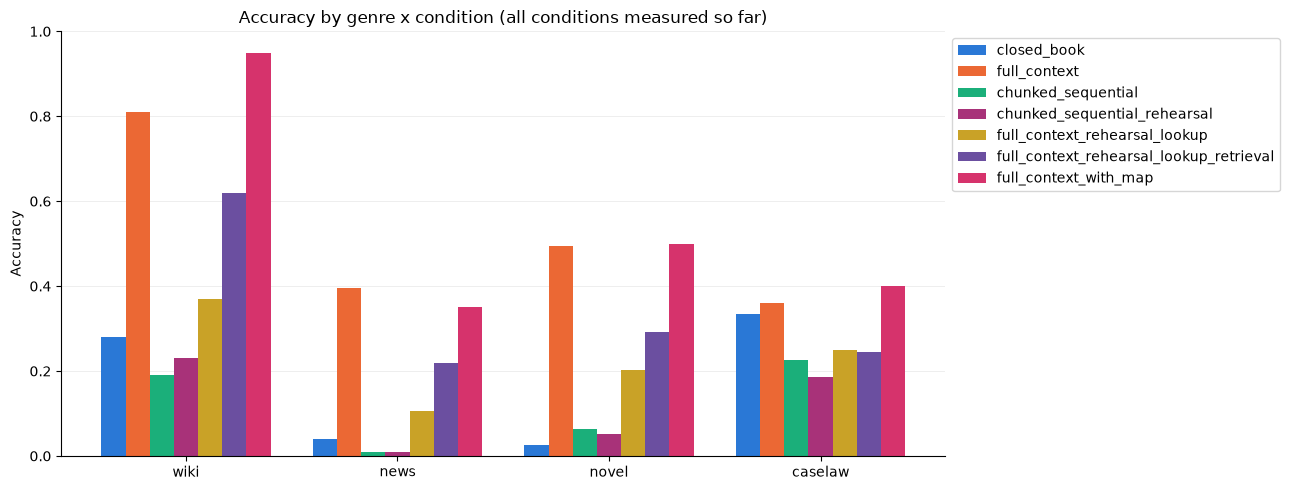

In [ ]:
acc_plot = accuracy.copy()
x = range(len(acc_plot))
bar_width = 0.8 / len(acc_plot.columns)
fig, ax = plt.subplots(figsize=(13, 5))
for i, condition in enumerate(acc_plot.columns):
    ax.bar([xi + i * bar_width for xi in x], acc_plot[condition], width=bar_width,
           label=condition, color=CONDITION_COLORS[condition])
ax.set_xticks([xi + bar_width * (len(acc_plot.columns) - 1) / 2 for xi in x])
ax.set_xticklabels(acc_plot.index)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by genre x condition (all conditions measured so far)")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

## Efficiency vs accuracy — is the extra cost worth it?

Tokens vs accuracy, one point per condition per genre — should sit right of full_context; question is whether also above it.


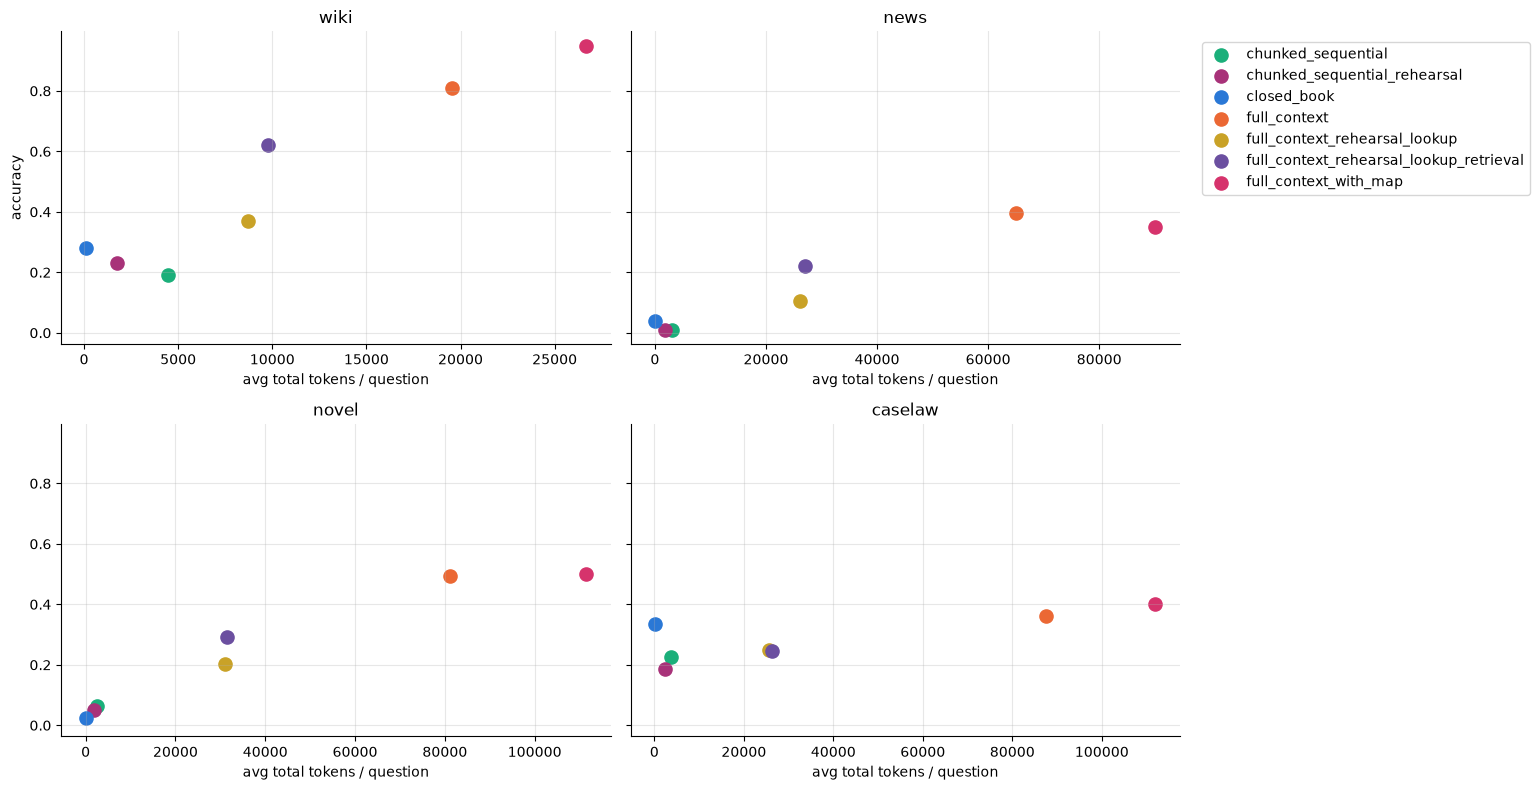

In [ ]:
efficiency = combined.groupby(["genre", "condition"]).agg(
    avg_tokens=("total_tokens", "mean"),
    accuracy=("correct", "mean"),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
axes = axes.flatten()
for ax, genre in zip(axes, GENRE_ORDER):
    sub = efficiency[efficiency["genre"] == genre]
    for _, r in sub.iterrows():
        if r["condition"] not in CONDITION_COLORS:
            continue
        ax.scatter(r["avg_tokens"], r["accuracy"], s=90, color=CONDITION_COLORS[r["condition"]], label=r["condition"])
    ax.set_title(genre)
    ax.set_xlabel("avg total tokens / question")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("accuracy")
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc="upper left", bbox_to_anchor=(1.0, 0.95))
plt.tight_layout()
plt.show()

## Summary

- **Hypothesis**: full text + gist map is a strict superset of `full_context`, should match/beat it (more tokens, not fewer).
- **Read per-genre, not pooled** — `10`'s pilot-scale wins didn't hold at full scale (wiki 0.850→0.620).
- **If this doesn't beat full_context either**: means the failure isn't about organization — points back to retrieval (`10`) or a better compressor (`07b`).
- **Scope**: reuses `07b`'s stage-2 checkpoint (drop +0.111 caveat). Caselaw `<HOLDING>` artifact still present.
